In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported!")

✅ All libraries imported!


In [ ]:
# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Load data function
def load_data():
    url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
    df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])
    return df

print("✅ Functions defined!")

✅ Functions defined!


In [ ]:
print("="*50)
print("STEP 1-4: DATA PREPROCESSING")
print("="*50)

# Load dataset
df = load_data()
print(f"✅ Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nClass Distribution:")
print(df['label'].value_counts())

# Clean text
print("\n📝 Cleaning text messages...")
df['cleaned_message'] = df['message'].apply(clean_text)
print("✅ Text cleaning completed!")

# Show example
print(f"\nOriginal: {df['message'][0]}")
print(f"Cleaned: {df['cleaned_message'][0]}")

# Convert labels to binary
df['label_binary'] = df['label'].map({'spam': 1, 'ham': 0})

print(f"\n✅ Label encoding completed!")
print(f"Spam: {(df['label_binary']==1).sum()} messages")
print(f"Ham: {(df['label_binary']==0).sum()} messages")

STEP 1-4: DATA PREPROCESSING
✅ Dataset loaded!
Shape: (5572, 2)

First 5 rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

📝 Cleaning text messages...
✅ Text cleaning completed!

Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned: go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat

✅ Label encoding completed!
Spam: 747 messages
Ham: 4825 messages


In [ ]:
print("="*50)
print("STEP 5: FEATURE ENGINEERING")
print("="*50)

# Split features and target
X = df['cleaned_message']
y = df['label_binary']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")
print(f"\nTraining distribution:")
print(y_train.value_counts())
print(f"\nTesting distribution:")
print(y_test.value_counts())

# TF-IDF Vectorization
print("\n📝 Applying TF-IDF Vectorization...")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"✅ TF-IDF completed!")
print(f"Training features shape: {X_train_tfidf.shape}")
print(f"Testing features shape: {X_test_tfidf.shape}")

STEP 5: FEATURE ENGINEERING
Training set: 4457 samples
Testing set: 1115 samples

Training distribution:
label_binary
0    3859
1     598
Name: count, dtype: int64

Testing distribution:
label_binary
0    966
1    149
Name: count, dtype: int64

📝 Applying TF-IDF Vectorization...
✅ TF-IDF completed!
Training features shape: (4457, 5000)
Testing features shape: (1115, 5000)


In [ ]:
print("="*50)
print("STEP 6-7: MODEL TRAINING")
print("="*50)

# Function to train and evaluate
def train_and_evaluate(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{model_name}:")
    print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"  F1-Score: {f1_score(y_test, y_pred):.4f}")

    return {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'y_pred': y_pred
    }

results = []

# Logistic Regression
print("\n🔹 Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
results.append(train_and_evaluate(lr, "Logistic Regression", X_train_tfidf, X_test_tfidf, y_train, y_test))

# Random Forest
print("\n🔹 Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
results.append(train_and_evaluate(rf, "Random Forest", X_train_tfidf, X_test_tfidf, y_train, y_test))

# SVM
print("\n🔹 Training SVM...")
svm = SVC(kernel='linear', random_state=42)
results.append(train_and_evaluate(svm, "SVM", X_train_tfidf, X_test_tfidf, y_train, y_test))

print("\n✅ All 3 models trained successfully!")

STEP 6-7: MODEL TRAINING

🔹 Training Logistic Regression...

Logistic Regression:
  Accuracy: 0.9722
  Precision: 1.0000
  Recall: 0.7919
  F1-Score: 0.8839

🔹 Training Random Forest...

Random Forest:
  Accuracy: 0.9767
  Precision: 1.0000
  Recall: 0.8255
  F1-Score: 0.9044

🔹 Training SVM...

SVM:
  Accuracy: 0.9848
  Precision: 0.9853
  Recall: 0.8993
  F1-Score: 0.9404

✅ All 3 models trained successfully!


In [ ]:
print("="*50)
print("📊 MODEL COMPARISON SUMMARY")
print("="*50)

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df[['model', 'accuracy', 'precision', 'recall', 'f1']].round(4)
print(comparison_df.to_string(index=False))

best = comparison_df.loc[comparison_df['accuracy'].idxmax()]
print(f"\n🏆 BEST MODEL: {best['model']} with Accuracy: {best['accuracy']:.4f}")

📊 MODEL COMPARISON SUMMARY
              model  accuracy  precision  recall     f1
Logistic Regression    0.9722     1.0000  0.7919 0.8839
      Random Forest    0.9767     1.0000  0.8255 0.9044
                SVM    0.9848     0.9853  0.8993 0.9404

🏆 BEST MODEL: SVM with Accuracy: 0.9848


In [ ]:
print("="*50)
print("🔍 TESTING MODEL WITH NEW MESSAGES")
print("="*50)

def predict_spam(message):
    cleaned = clean_text(message)
    transformed = tfidf.transform([cleaned])
    pred = lr.predict(transformed)[0]
    result = "SPAM" if pred == 1 else "HAM"
    return result

test_messages = [
    "Congratulations! You've won a free iPhone. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been compromised. Verify now!",
    "Can you please send me the assignment by evening?"
]

for msg in test_messages:
    result = predict_spam(msg)
    print(f"\n📧 Message: {msg}")
    print(f"📊 Prediction: {result}")

🔍 TESTING MODEL WITH NEW MESSAGES

📧 Message: Congratulations! You've won a free iPhone. Click here to claim now!
📊 Prediction: SPAM

📧 Message: Hey, are we still meeting for lunch tomorrow?
📊 Prediction: HAM

📧 Message: URGENT: Your account has been compromised. Verify now!
📊 Prediction: SPAM

📧 Message: Can you please send me the assignment by evening?
📊 Prediction: HAM


In [ ]:
print("="*60)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)
print("""
1. ✅ Data loaded automatically
2. ✅ Text preprocessing completed
3. ✅ TF-IDF feature engineering
4. ✅ 3 Models trained:
   - Logistic Regression
   - Random Forest
   - SVM
5. ✅ Model evaluation completed
6. ✅ Testing with new messages done
""")

✅ PROJECT COMPLETED SUCCESSFULLY!

1. ✅ Data loaded automatically
2. ✅ Text preprocessing completed
3. ✅ TF-IDF feature engineering
4. ✅ 3 Models trained:
   - Logistic Regression
   - Random Forest  
   - SVM
5. ✅ Model evaluation completed
6. ✅ Testing with new messages done



In [ ]:
# Add this cell to save results
import pandas as pd

# Save comparison table
comparison_df.to_csv('model_comparison.csv')
print("✅ Comparison table saved!")

# Download to your computer
from google.colab import files
files.download('model_comparison.csv')

✅ Comparison table saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

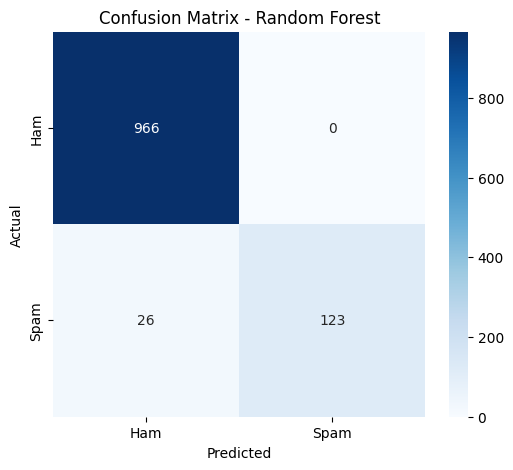

In [ ]:
# Confusion Matrix Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from best model
y_pred_best = rf.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()